Input Diameter: 7.2409
Latent Diameter: 10.2877
Scaling Factor: 0.7038
MSE: 0.078813
SMAPE: 14.36%


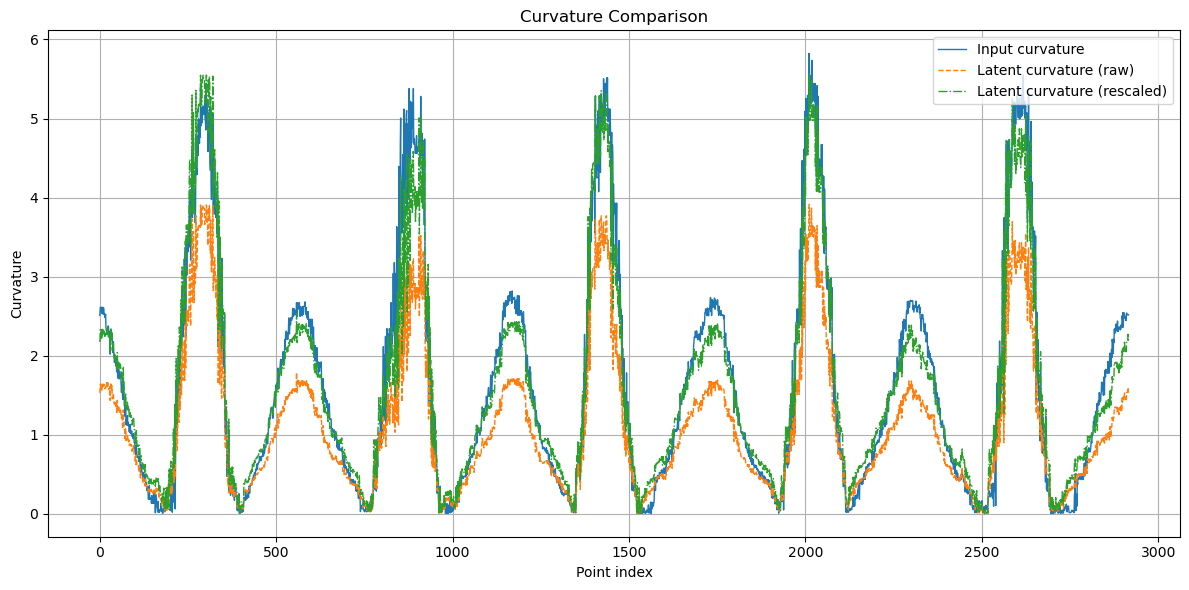

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
# Load data
path = "../OLD_notebooks_euclid_ae/curvatures/curvatures_exp03_ae_flower_curve_w100_b64.pt"
data = torch.load(path, map_location='cpu', weights_only=False)

latents = data["points_sub"][1].float()
inputs = data["points_sub"][0].float()

# Convert curvatures to torch tensors
curv_latents = torch.from_numpy(data["curvatures_sub"][3]).float()
curv_inputs = torch.from_numpy(data["curvatures_sub"][1]).float()

def compute_bounding_box_diameter(x: torch.Tensor) -> float:
    min_vals, _ = x.min(dim=0)
    max_vals, _ = x.max(dim=0)
    return torch.norm(max_vals - min_vals, p=2).item()

# Compute diameters
diam_input = compute_bounding_box_diameter(inputs)
diam_latent = compute_bounding_box_diameter(latents)

# Rescale latent curvature
scale = diam_input / diam_latent
curv_latents_rescaled = curv_latents / scale

# Ensure shapes match
assert curv_latents_rescaled.shape == curv_inputs.shape, \
    f"Shape mismatch: {curv_latents_rescaled.shape} vs {curv_inputs.shape}"

# Compute MSE and SMAPE
mse = F.mse_loss(curv_latents_rescaled, curv_inputs)
numerator = torch.abs(curv_latents_rescaled - curv_inputs)
denominator = (torch.abs(curv_latents_rescaled) + torch.abs(curv_inputs)).clamp(min=1e-8)
smape = 100 * torch.mean(numerator / denominator)

# Output metrics
print(f"Input Diameter: {diam_input:.4f}")
print(f"Latent Diameter: {diam_latent:.4f}")
print(f"Scaling Factor: {scale:.4f}")
print(f"MSE: {mse.item():.6f}")
print(f"SMAPE: {smape.item():.2f}%")

# Plot curvature comparison
plt.figure(figsize=(12, 6))
plt.plot(curv_inputs.numpy(), label='Input curvature', linewidth=1)
plt.plot(curv_latents.numpy(), label='Latent curvature (raw)', linestyle='--', linewidth=1)
plt.plot(curv_latents_rescaled.numpy(), label='Latent curvature (rescaled)', linestyle='-.', linewidth=1)
plt.title('Curvature Comparison')
plt.xlabel('Point index')
plt.ylabel('Curvature')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
